In [2]:
import os
from matplotlib.path import Path
import numpy as np
import pandas as pd

!pip install -qqq contextily
!pip install -qqq geopandas
!pip install -qqq geodatasets
import contextily as ctx
import geodatasets
import geopandas as gpd

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path as SystemPath


ruta_paises = SystemPath("data/paises")
ruta_salida = SystemPath("data/unificado")

ruta_salida.mkdir(parents=True, exist_ok=True)

patron_busqueda = str(ruta_paises / "modis_2024_*.csv")
archivos_csv = glob.glob(patron_busqueda)

# Define the path for the unified (uncleaned) CSV
ruta_archivo_unificado = ruta_salida / "modis_2024_unificado.csv"

if archivos_csv:
    lista_dataframes = []

    for ruta_str in archivos_csv:
        archivo = SystemPath(ruta_str)
        pais = archivo.stem.replace("modis_2024_", "").capitalize()

        df_temporal = pd.read_csv(archivo)
        df_temporal['pais'] = pais
        lista_dataframes.append(df_temporal)

    df_unificado = pd.concat(lista_dataframes, ignore_index=True)

    df_unificado.to_csv(ruta_archivo_unificado, index=False)
    df = pd.read_csv(ruta_archivo_unificado) # Load the newly created unified df
else:
    # If no raw files are found, check for the already 'cleaned' version.
    # This assumes the user wants to proceed with available data.
    ruta_archivo_limpio_existente = SystemPath("data/modis_2024_unificado_limpio.csv")
    if ruta_archivo_limpio_existente.exists():
        print(f"Advertencia: No se encontraron archivos en '{ruta_paises}'. Se cargará '{ruta_archivo_limpio_existente}' como fallback.")
        df = pd.read_csv(ruta_archivo_limpio_existente)
    else:
        print(f"Error: No se encontraron archivos en '{ruta_paises}' ni existe el archivo limpio '{ruta_archivo_limpio_existente}'. Creando DataFrame vacío.")
        df = pd.DataFrame()

Advertencia: No se encontraron archivos en 'data/paises'. Se cargará 'data/modis_2024_unificado_limpio.csv' como fallback.


## **Limpieza**

#### **Limpieza y Formateo de Fechas/Horas**

In [3]:
info_df = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores No Nulos': df.count(),
    'Valores Nulos': df.isnull().sum(),
    '% de Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})

print(" 1. INFO DE DATOS Y CALIDAD:")
display(info_df)  # Usamos display para mostrar ambas tablas de forma interactiva

print("\n 2. VISTA PREVIA DEL DATASET (Primeros registros):")
df.head()

 1. INFO DE DATOS Y CALIDAD:


,Tipo de Dato,Valores No Nulos,Valores Nulos,% de Nulos
latitude,float64,308402,0,0.0
longitude,float64,308402,0,0.0
brightness,float64,308402,0,0.0
scan,float64,308402,0,0.0
track,float64,308402,0,0.0
acq_date,object,308402,0,0.0
acq_time,int64,308402,0,0.0
satellite,object,308402,0,0.0
instrument,object,308402,0,0.0
confidence,int64,308402,0,0.0



 2. VISTA PREVIA DEL DATASET (Primeros registros):


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,pais,acq_datetime
0,40.8143,19.6998,300.5,1.1,1.1,2024-01-28,853,Terra,MODIS,37,61.03,280.8,7.9,D,NaN,Albania,2024-01-28 08:53:00
1,40.4384,19.7503,319.6,1.0,1.0,2024-01-28,1218,Aqua,MODIS,79,61.03,285.4,20.4,D,NaN,Albania,2024-01-28 12:18:00
2,40.2651,19.8576,302.3,2.1,1.4,2024-01-31,1244,Aqua,MODIS,49,61.03,286.7,19.0,D,NaN,Albania,2024-01-31 12:44:00
3,39.8510,20.2340,301.5,1.0,1.0,2024-02-04,1213,Aqua,MODIS,35,61.03,288.9,5.3,D,NaN,Albania,2024-02-04 12:13:00
4,40.5204,20.3950,304.2,1.0,1.0,2024-02-04,1213,Aqua,MODIS,46,61.03,288.5,6.3,D,NaN,Albania,2024-02-04 12:13:00


In [4]:
# Convertir la columna 'fecha' a tipo datetime
df['acq_date'] = pd.to_datetime(df['acq_date'], format='%Y-%m-%d')

# Formatear 'acq_time' para que sea consistente con 0 a la izquierda
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)

# Creamos columna 'acq_datetime' combinando 'acq_date' y 'acq_time'
df['acq_datetime'] = pd.to_datetime(
    df['acq_date'].dt.strftime('%Y-%m-%d') + ' ' + df['acq_time'].str[:2] + ':' + df['acq_time'].str[2:4], format='%Y-%m-%d %H:%M')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308402 entries, 0 to 308401
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   latitude      308402 non-null  float64       
 1   longitude     308402 non-null  float64       
 2   brightness    308402 non-null  float64       
 3   scan          308402 non-null  float64       
 4   track         308402 non-null  float64       
 5   acq_date      308402 non-null  datetime64[ns]
 6   acq_time      308402 non-null  object        
 7   satellite     308402 non-null  object        
 8   instrument    308402 non-null  object        
 9   confidence    308402 non-null  int64         
 10  version       308402 non-null  float64       
 11  bright_t31    308402 non-null  float64       
 12  frp           308402 non-null  float64       
 13  daynight      308402 non-null  object        
 14  type          0 non-null       float64       
 15  pais          308

#### **Validación y Filtrado de Calidad**

In [5]:
# Filtrar registros de coordenadas
# Latitud debe estar entre -90 y 90, longitud entre -180 y 180
df = df[
    (df['latitude'].between(-90, 90)) &
    (df['longitude'].between(-180, 180)) &
    (df['latitude'].notnull()) &
    (df['longitude'].notnull())
]

df = df[df['confidence'].between(0, 100)]


#### **Estandarizacion**

In [6]:
# Convertir variables categóricas para optimizar memoria
df['satellite'] = df['satellite'].astype('category')
df['instrument'] = df['instrument'].astype('category')
df['daynight'] = df['daynight'].astype('category')
df['pais'] = df['pais'].astype('category')
df['type'] = df['type'].astype('category') # tipo de foco (forestal, volcán...)

# Redondear variables numéricas para homogeneizar datos y reducir memoria
df['brightness'] = df['brightness'].round(2) # temperatura de brillo del pixel medida en Kelvin (temperatura observada desde el espacio en la zona más caliente)
df['bright_t31'] = df['bright_t31'].round(2) # temperatura de brillo del pixel medida en infra-rojo (band 31) (temperatura de la superficie terrestre)
# brightness y bright_t31 se usan para contrastar y distinguir un incendio de otros objetos calientes (asfalto, volcanes)
df['frp'] = df['frp'].round(2) # fire radiative power (potencia radiactiva del fuego) medida en MW (megavatios). Es un indicador de la intensidad del incendio.

In [7]:
# Diccionario de mapeo oficial de MODIS
diccionario_tipos = {
    0: 'Incendio forestal/vegetación',
    1: 'Volcán',
    2: 'Industria/Foco estático',
    3: 'Otros/Fuera de rango'
}

# La columna 'type' ya contiene los nombres de las categorías directamente.
# El mapeo directo de un diccionario donde las claves no coinciden con los valores
# actuales de 'type' resultaría en NaNs. Por lo tanto, se omite esta línea.
# df['type'] = df['type'].map(diccionario_tipos)

# Asegurarnos de que se guarde como tipo categoría para optimizar
df['type'] = df['type'].astype('category')

# Verificar el cambio
print(df['type'].value_counts())

Series([], Name: count, dtype: int64)


In [8]:
# 1. Crear la carpeta 'data' si no existe en el entorno
os.makedirs('data', exist_ok=True)

# 2. Modificar la ruta de salida para incluir la carpeta
archivo_salida = 'data/modis_2024_unificado_limpio.csv'

# Guardar los datos limpios dentro de la carpeta (Cambiado df_clean por df)
df.to_csv(archivo_salida, index=False)

print(f"Dimensiones finales tras la limpieza: {df.shape}")
print(f"¡Base de datos limpia guardada como '{archivo_salida}'!")

df_clean = pd.read_csv(r'data/modis_2024_unificado_limpio.csv')
df_clean.head()



Dimensiones finales tras la limpieza: (308402, 17)
¡Base de datos limpia guardada como 'data/modis_2024_unificado_limpio.csv'!


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,pais,acq_datetime
0,40.8143,19.6998,300.5,1.1,1.1,2024-01-28,853,Terra,MODIS,37,61.03,280.8,7.9,D,NaN,Albania,2024-01-28 08:53:00
1,40.4384,19.7503,319.6,1.0,1.0,2024-01-28,1218,Aqua,MODIS,79,61.03,285.4,20.4,D,NaN,Albania,2024-01-28 12:18:00
2,40.2651,19.8576,302.3,2.1,1.4,2024-01-31,1244,Aqua,MODIS,49,61.03,286.7,19.0,D,NaN,Albania,2024-01-31 12:44:00
3,39.8510,20.2340,301.5,1.0,1.0,2024-02-04,1213,Aqua,MODIS,35,61.03,288.9,5.3,D,NaN,Albania,2024-02-04 12:13:00
4,40.5204,20.3950,304.2,1.0,1.0,2024-02-04,1213,Aqua,MODIS,46,61.03,288.5,6.3,D,NaN,Albania,2024-02-04 12:13:00


## **Calida de los datos**

#### **Análisis de Calidad y Filtro de Ruido**

In [9]:
# Analizar la distribución de la calidad antes de limpiar
print("Distribución original de confianza:")
print(df_clean['confidence'].describe())

# Aplicar el filtro de ruido: Quedarnos solo con alertas de confianza Media y Alta (>= 50%)
df_sin_ruido = df_clean[df_clean['confidence'] >= 50].copy()

print(f"\nRegistros originales: {len(df_clean)}")
print(f"Registros tras eliminar ruido: {len(df_sin_ruido)}")
print(f"Falsos positivos/Ruido eliminado: {len(df_clean) - len(df_sin_ruido)} alertas.")

Distribución original de confianza:
count    308402.000000
mean         66.089393
std          24.753513
min           0.000000
25%          50.000000
50%          69.000000
75%          86.000000
max         100.000000
Name: confidence, dtype: float64

Registros originales: 308402
Registros tras eliminar ruido: 231964
Falsos positivos/Ruido eliminado: 76438 alertas.


Distribución de los niveles de confianza:
count    308402.000000
mean         66.089393
std          24.753513
min           0.000000
25%          50.000000
50%          69.000000
75%          86.000000
max         100.000000
Name: confidence, dtype: float64


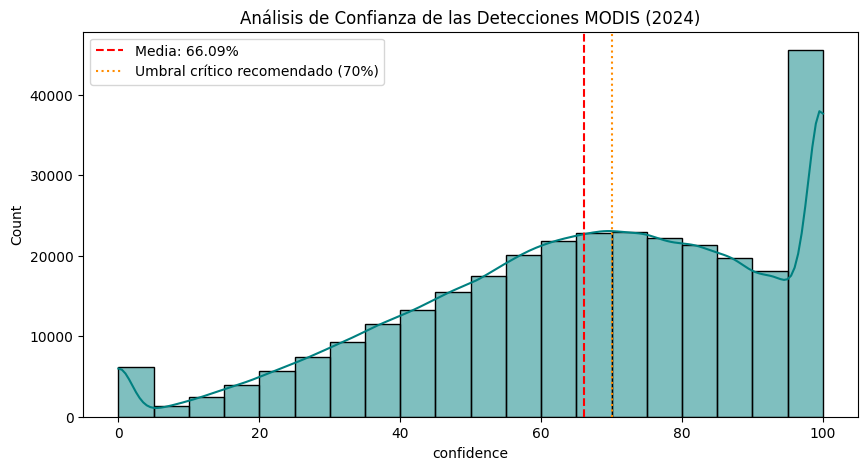

Registros iniciales: 308402 | Registros de alta confianza: 149734


In [10]:
# Resumen de calidad
print("Distribución de los niveles de confianza:")
print(df['confidence'].describe())

# Visualización de la pureza del dato
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='confidence', kde=True, bins=20, color='teal')
plt.axvline(df['confidence'].mean(), color='red', linestyle='--', label=f"Media: {df['confidence'].mean():.2f}%")
plt.axvline(70, color='darkorange', linestyle=':', label="Umbral crítico recomendado (70%)")
plt.title('Análisis de Confianza de las Detecciones MODIS (2024)')
plt.legend()
plt.show()

# Propuesta de filtrado para análisis de alta certeza
df_high_conf = df[df['confidence'] >= 70]
print(f"Registros iniciales: {len(df)} | Registros de alta confianza: {len(df_high_conf)}")

/tmp/ipykernel_64978/595022279.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_64978/595022279.py:29: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


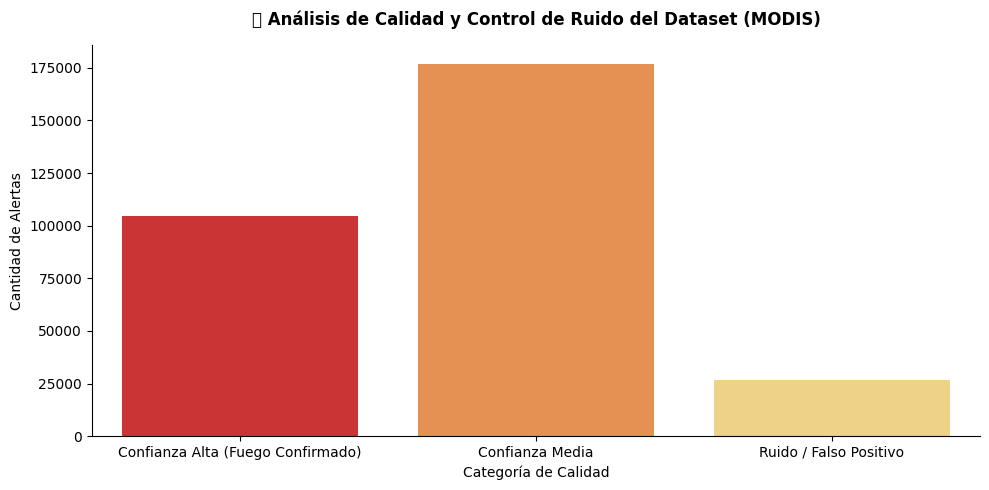

In [11]:
# Crear categorías de calidad basadas en el estándar MODIS
def clasificar_calidad(conf):
    if conf < 30:
        return 'Ruido / Falso Positivo'
    elif conf < 80:
        return 'Confianza Media'
    else:
        return 'Confianza Alta (Fuego Confirmado)'

# Aplicar la clasificación
df_clean['calidad_alerta'] = df_clean['confidence'].apply(clasificar_calidad)

# Graficar el análisis de calidad para la presentación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_clean,
    x='calidad_alerta',
    palette='YlOrRd_r',
    order=['Confianza Alta (Fuego Confirmado)', 'Confianza Media', 'Ruido / Falso Positivo']
)

plt.title('🛡️ Análisis de Calidad y Control de Ruido del Dataset (MODIS)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Categoría de Calidad', fontsize=10)
plt.ylabel('Cantidad de Alertas', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## **Iterpretacion Grafica**

#### **Análisis de Frecuencia por País**

/tmp/ipykernel_64978/3150678771.py:14: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


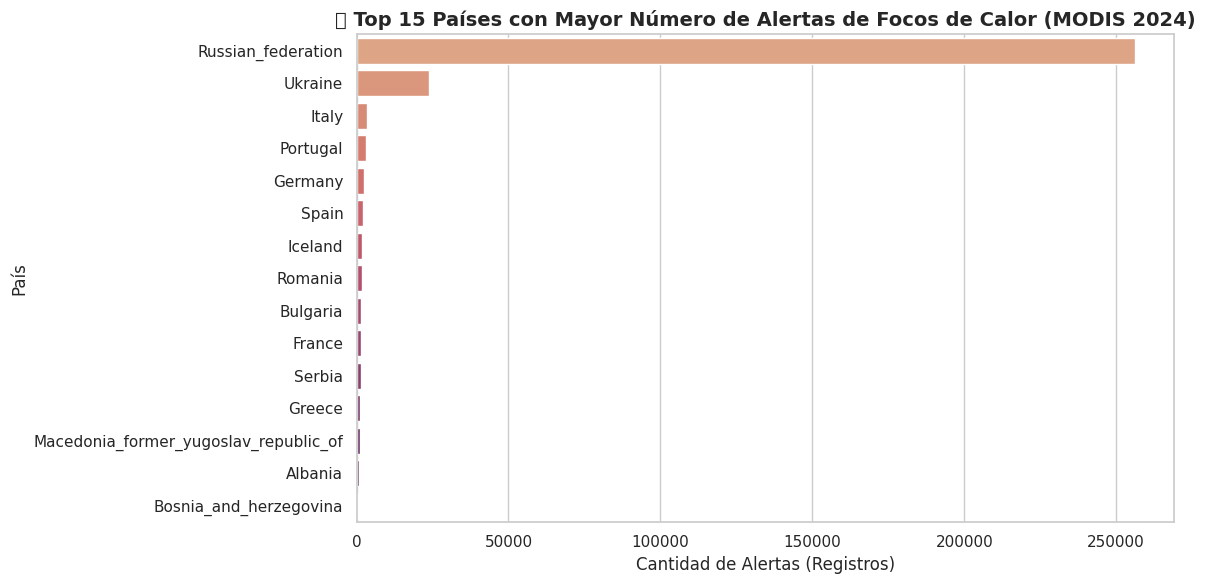

In [12]:
# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Contar registros por país y seleccionar los 15 principales
top_paises = df_clean['pais'].value_counts().head(15)

# Crear gráfico de barras
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, palette="flare", legend=False)

plt.title('🔥 Top 15 Países con Mayor Número de Alertas de Focos de Calor (MODIS 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Alertas (Registros)', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

#### **Comportamiento Temporal (Evolución por Meses)**

/tmp/ipykernel_64978/3832483875.py:36: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


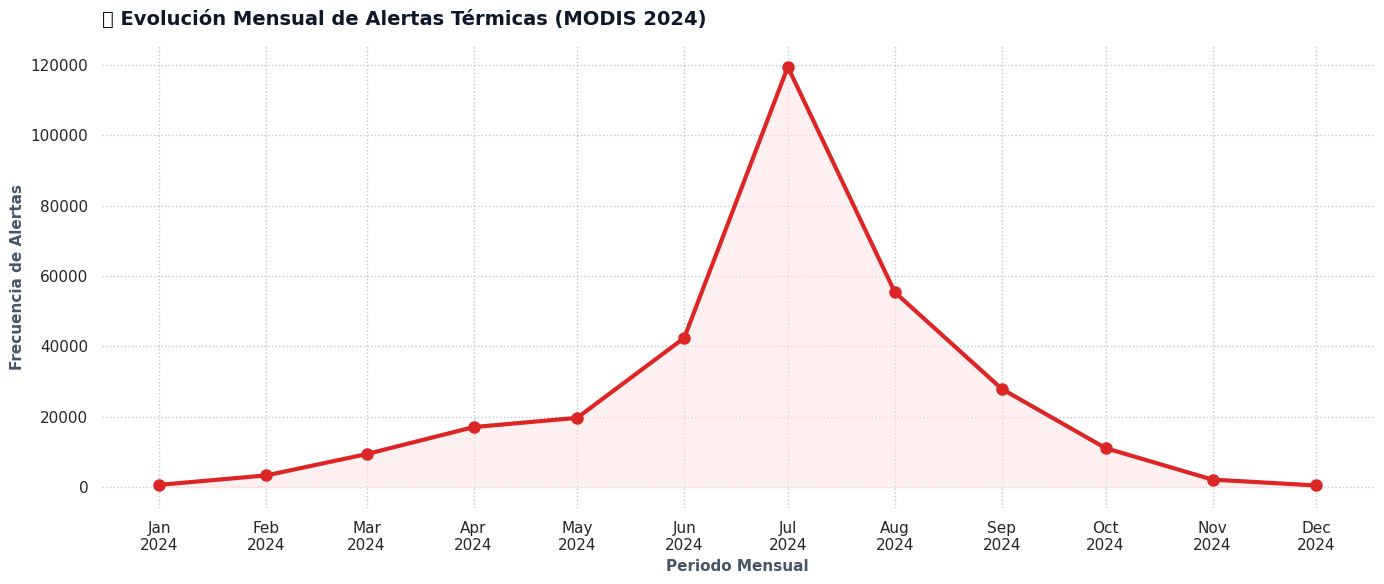

In [13]:
# 1. Estética nativa de Jupyter
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

def plot_temporal_evolution(dataframe):
    fig, ax = plt.subplots(figsize=(14, 6))

    # === EL BLINDAJE REAL ===
    # Forzamos la conversión aquí mismo en una variable nueva
    fechas_correctas = pd.to_datetime(dataframe['acq_datetime'], errors='coerce')

    # ¡OJO AQUÍ!: Agrupamos usando 'fechas_correctas', NO 'dataframe'
    focos_por_mes = dataframe.groupby(fechas_correctas.dt.to_period('M')).size()
    focos_por_mes.index = focos_por_mes.index.to_timestamp()

    # 2. Gráfico y sombreado
    ax.plot(focos_por_mes.index, focos_por_mes.values,
            marker='o', markersize=8, color='#dc2626', linewidth=3)

    ax.fill_between(focos_por_mes.index, focos_por_mes.values,
                    color='#fee2e2', alpha=0.5)

    # 3. Formato de fechas en el eje X
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    # 4. Etiquetas
    ax.set_title('📅 Evolución Mensual de Alertas Térmicas (MODIS 2024)',
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a')
    ax.set_xlabel('Periodo Mensual', fontsize=11, fontweight='semibold', color='#475569')
    ax.set_ylabel('Frecuencia de Alertas', fontsize=11, fontweight='semibold', color='#475569')

    ax.grid(True, linestyle=':', alpha=0.6, color='#94a3b8')
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    return fig

# Lanzar el gráfico con tu df_clean
fig = plot_temporal_evolution(df_clean)
plt.show()

#### **Análisis de Dinámica Temporal y Estacionalidad de 2024**


📊 --- Comportamiento Agregado por Criterio Temporal ---
 mes_num mes_nombre trimestre  total_detecciones  frp_promedio  frp_maximo  confianza_media
       1        Ene        Q1                573     48.928272      2761.1        59.291449
       2        Feb        Q1               3262     25.254660      1337.9        60.426732
       3        Mar        Q1               9320     39.839378      2145.3        61.601073
       4        Abr        Q2              17010     38.466796      2572.6        63.724162
       5        May        Q2              19644     53.956205      9210.4        66.467216
       6        Jun        Q2              42383     54.495512      4161.2        65.083288
       7        Jul        Q3             119511     53.878182      5797.3        67.603877
       8        Ago        Q3              55367     53.518347      5696.2        65.773042
       9        Sep        Q3              27842     46.503689      5184.5        66.438079
      10        Oct    

/tmp/ipykernel_64978/356677911.py:73: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


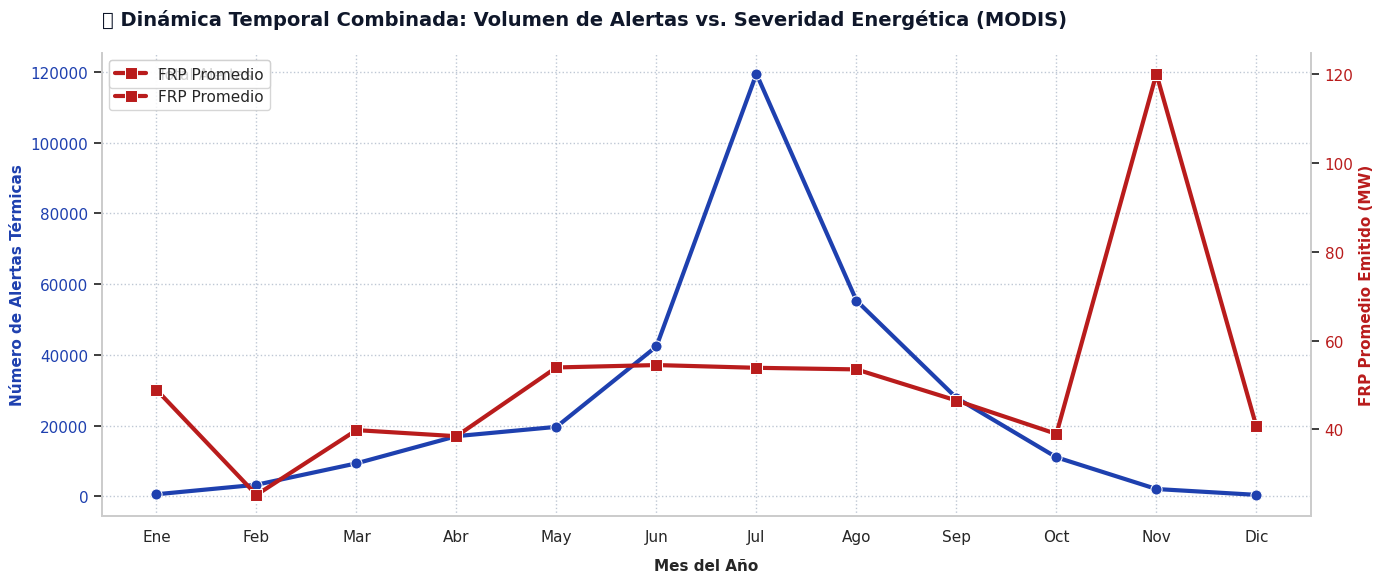

In [14]:
# 1. Configurar estética nativa de Jupyter / Colab
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

def generar_analisis_temporal_avanzado(dataframe):
    # Clonamos para no alterar el dataframe original
    df_temp = dataframe.copy()

    # Parsing estricto garantizado
    df_temp['acq_date'] = pd.to_datetime(df_temp['acq_date'], errors='coerce')

    # Crear características temporales legibles
    df_temp['mes_num'] = df_temp['acq_date'].dt.month

    # Diccionario para forzar los nombres de los meses en español (evita problemas de locale en Colab)
    meses_es = {
        1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
    }
    df_temp['mes_nombre'] = df_temp['mes_num'].map(meses_es)
    df_temp['trimestre'] = 'Q' + df_temp['acq_date'].dt.quarter.astype(str)

    # 2. Agrupación temporal corregida
    tabla_temporal = df_temp.groupby(['mes_num', 'mes_nombre', 'trimestre']).agg(
        total_detecciones=('frp', 'count'),
        frp_promedio=('frp', 'mean'),
        frp_maximo=('frp', 'max'),
        confianza_media=('confidence', 'mean')
    ).reset_index().sort_values('mes_num')

    print("\n📊 --- Comportamiento Agregado por Criterio Temporal ---")
    print(tabla_temporal.to_string(index=False))

    # 3. Construcción del Gráfico de Líneas Multieje Profesional
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Primer Eje (Izquierdo): Volumetría de alertas
    color_alertas = '#1e40af' # Azul oscuro técnico
    ax1.set_xlabel('Mes del Año', fontsize=11, fontweight='semibold', labelpad=10)
    ax1.set_ylabel('Número de Alertas Térmicas', color=color_alertas, fontsize=11, fontweight='semibold')

    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='total_detecciones',
        marker='o', markersize=8, color=color_alertas, ax=ax1, linewidth=3, label='Total Alertas'
    )
    ax1.tick_params(axis='y', labelcolor=color_alertas)
    ax1.grid(True, linestyle=':', alpha=0.6, color='#94a3b8') # Rejilla sutil de fondo

    # Segundo Eje (Derecho): Severidad Energética (FRP)
    ax2 = ax1.twinx()
    color_frp = '#b91c1c' # Rojo fuego premium
    ax2.set_ylabel('FRP Promedio Emitido (MW)', color=color_frp, fontsize=11, fontweight='semibold')

    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='frp_promedio',
        marker='s', markersize=8, color=color_frp, ax=ax2, linewidth=3, label='FRP Promedio'
    )
    ax2.tick_params(axis='y', labelcolor=color_frp)
    ax2.grid(False) # Evitamos que las rejillas se crucen

    # Unificar leyendas de ambos ejes en una sola esquina limpia
    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', frameon=True)

    # Títulos y limpieza de bordes
    plt.title('📅 Dinámica Temporal Combinada: Volumen de Alertas vs. Severidad Energética (MODIS)',
              fontsize=14, fontweight='bold', color='#0f172a', pad=20, loc='left')

    sns.despine(ax=ax1, top=True, left=False, right=False)
    sns.despine(ax=ax2, top=True, left=False, right=False)

    plt.tight_layout()
    return fig, tabla_temporal

# Lanzar proceso usando tu DataFrame df_clean
fig, tabla_resumen = generar_analisis_temporal_avanzado(df_clean)
plt.show()

#### **Análisis de Patrones Temporales y Estacionalidad**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


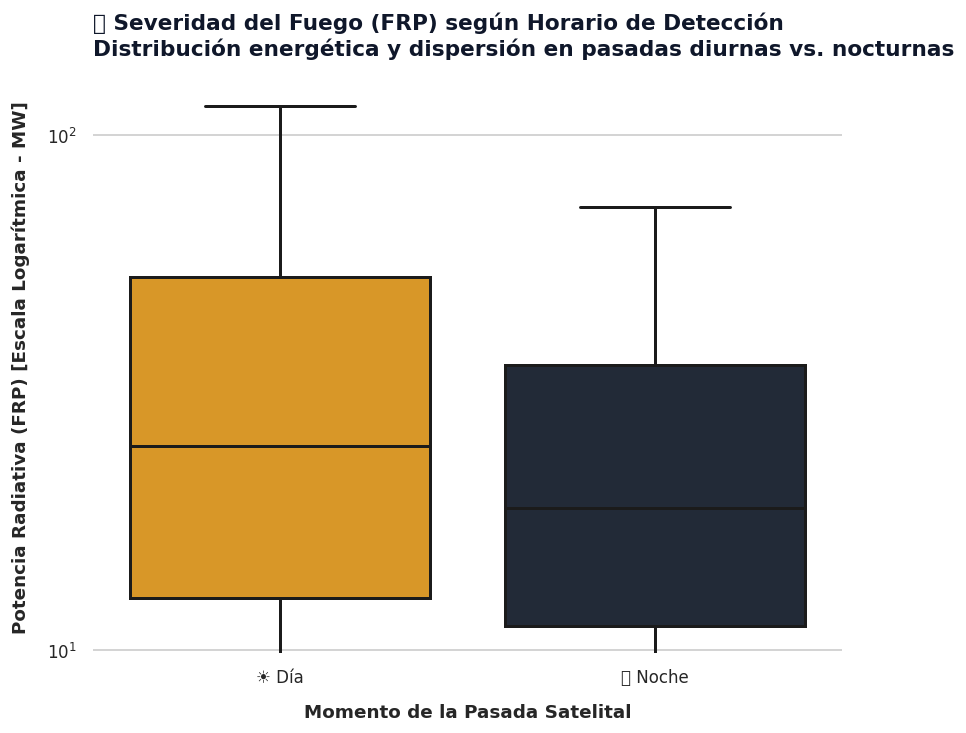

In [15]:
# 1. Configurar estética de alta definición
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 120  # Nitidez óptima

def plot_fire_severity_day_night(dataframe):
    # Crear copia interna para evitar SettingWithCopyWarning
    df_temp = dataframe.copy()

    # Comprobación de seguridad para la columna daynight
    if 'daynight' not in df_temp.columns:
        raise ValueError("El DataFrame no contiene la columna 'daynight'")

    # SOLUCON ANTI-CHOF: Definimos una proporción vertical/cuadrada saludable
    # Un boxplot de pocas categorías (Día vs Noche) se ve mejor en formato 7x6 o similar
    fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")

    # Mapeo estético para que el eje X sea totalmente explícito y elegante
    df_temp['daynight_label'] = df_temp['daynight'].map({'D': '☀️ Día', 'N': '🌙 Noche'})

    # 2. Gráfico de caja (Boxplot) de Alta Fidelidad
    sns.boxplot(
        ax=ax,
        data=df_temp,
        x='daynight_label',
        y='frp',
        hue='daynight_label',
        showfliers=False,       # Oculta outliers extremos para que la caja "respire" bien
        palette=['#f59e0b', '#1e293b'], # Ámbar para el día, Pizarra oscuro para la noche
        linewidth=1.8,
        legend=False
    )

    # 3. Escala adaptativa inteligente (Logarítmica si los datos están muy dispersos)
    if df_temp['frp'].max() / df_temp['frp'].median() > 15:
        ax.set_yscale('log')
        ax.set_ylabel('Potencia Radiativa (FRP) [Escala Logarítmica - MW]', fontsize=11, fontweight='semibold', labelpad=10)
    else:
        ax.set_ylabel('Potencia Radiativa del Fuego (FRP - MW)', fontsize=11, fontweight='semibold', labelpad=10)

    # 4. Refinamiento de etiquetas y títulos estilo Dashboard Senior
    ax.set_xlabel('Momento de la Pasada Satelital', fontsize=11, fontweight='semibold', labelpad=10)
    ax.tick_params(labelsize=10)

    plt.title('🔥 Severidad del Fuego (FRP) según Horario de Detección\n'
              'Distribución energética y dispersión en pasadas diurnas vs. nocturnas',
              fontsize=13, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.3)

    # Limpieza de bordes innecesarios
    sns.despine(left=True, bottom=True)

    return fig

# Lanzamiento directo sobre tu df_clean
fig_severity = plot_fire_severity_day_night(df_clean)
plt.show()

#### **Análisis de Intensidad (Distribución de FRP y Brillo)**

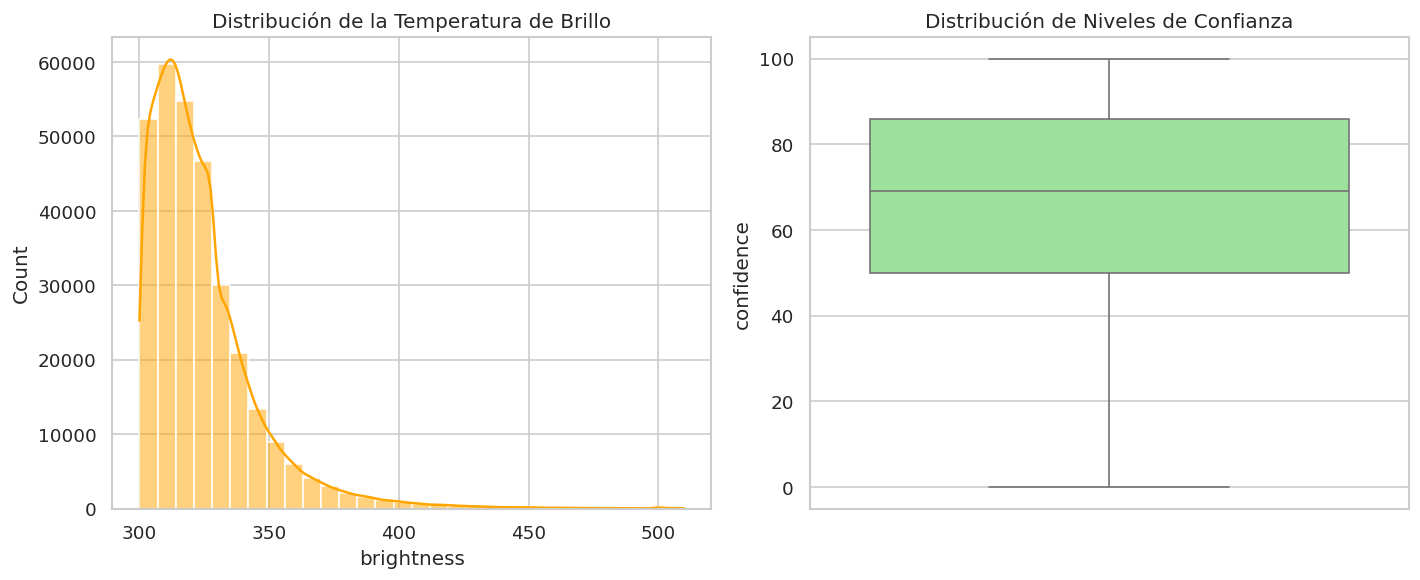

In [16]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Histograma de la potencia radiativa del fuego (FRP) o brillo
plt.subplot(1, 2, 1)
sns.histplot(df['brightness'], bins=30, kde=True, color='orange')
plt.title('Distribución de la Temperatura de Brillo')

# Boxplot de Confianza para ver si hay anomalías o ruido
plt.subplot(1, 2, 2)
sns.boxplot(y=df['confidence'], color='lightgreen')
plt.title('Distribución de Niveles de Confianza')

plt.tight_layout()
plt.show()

#### **Distribución Geoespacial Rápida (Scatter Plot)**

/tmp/ipykernel_64978/458028765.py:54: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


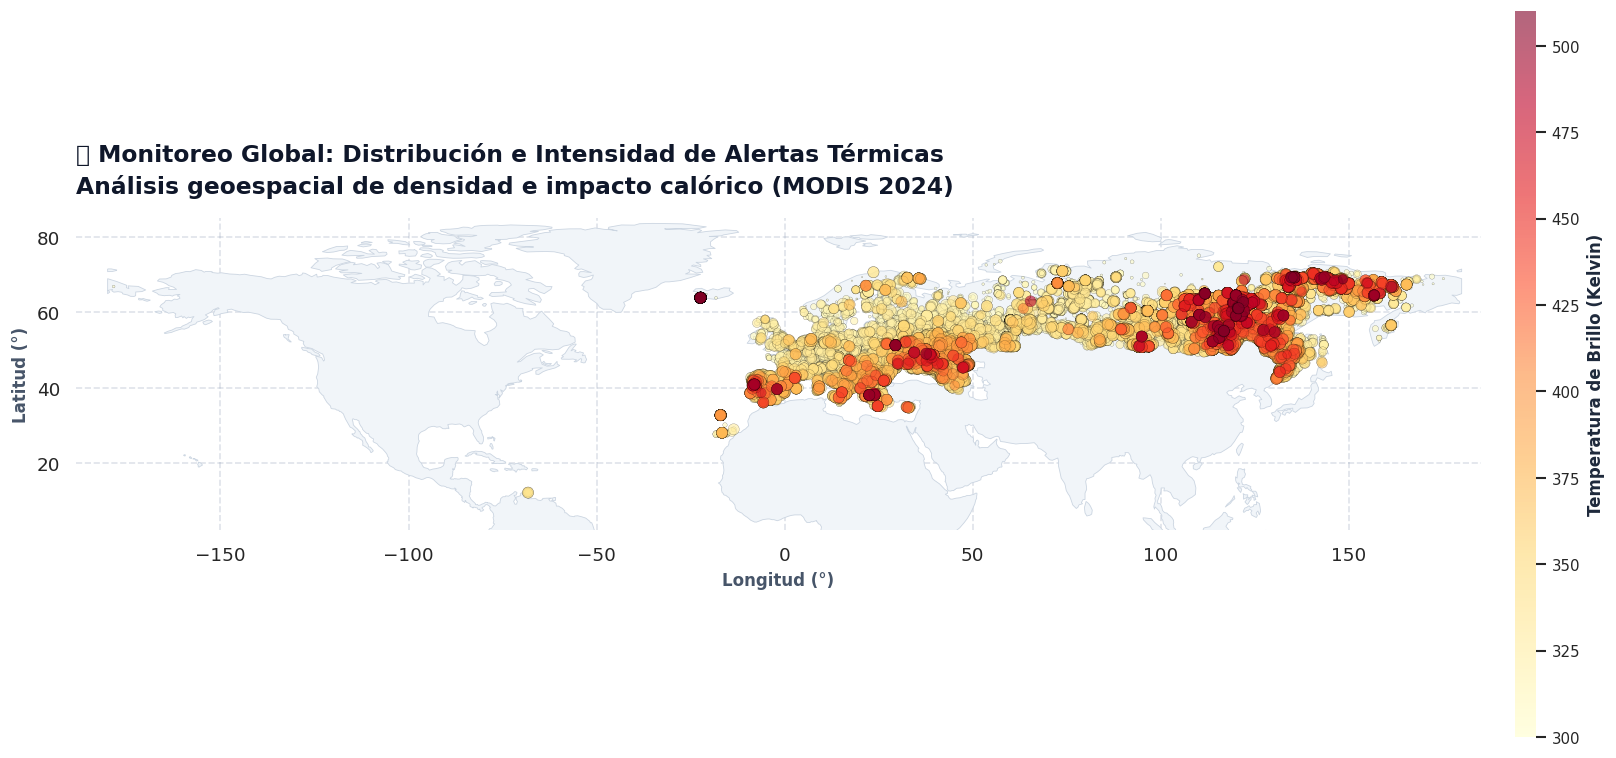

In [17]:
# 1. Configurar entorno estético nativo de Jupyter
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 120

def render_pro_map_with_background(dataframe):
    fig, ax = plt.subplots(figsize=(15, 9))

    # === SOLUCIÓN: Cargar el mapa desde el nuevo paquete oficial ===
    url_world = geodatasets.get_path("naturalearth.land")
    world = gpd.read_file(url_world)
    world.plot(ax=ax, color='#f1f5f9', edgecolor='#cbd5e1', linewidth=0.5)

    # 2. Pipeline de datos: Evitar Overplotting (Fuegos intensos al frente)
    df_sorted = dataframe.sort_values(by='brightness', ascending=True)

    # Escalado semántico para el tamaño basado en confianza
    sizes = (df_sorted['confidence'] / 100) ** 2 * 45

    # 3. Renderizado de las Alertas Térmicas sobre el mapa
    scatter = ax.scatter(
        x=df_sorted['longitude'],
        y=df_sorted['latitude'],
        c=df_sorted['brightness'],
        s=sizes,
        cmap='YlOrRd',
        alpha=0.6,
        edgecolors='black',
        linewidths=0.15,
        zorder=3             # Garantiza que los puntos queden por encima del mapa
    )

    # 4. Estilizado de la barra de color
    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, aspect=35, shrink=0.7)
    cbar.set_label('Temperatura de Brillo (Kelvin)', fontsize=10, fontweight='semibold', color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False)

    # 5. Límites geográficos adaptados a tus datos
    ax.set_xlim(dataframe['longitude'].min() - 10, dataframe['longitude'].max() + 10)
    ax.set_ylim(dataframe['latitude'].min() - 10, dataframe['latitude'].max() + 10)

    # 6. Arquitectura de Diseño
    ax.set_title('🔥 Monitoreo Global: Distribución e Intensidad de Alertas Térmicas\n'
                 'Análisis geoespacial de densidad e impacto calórico (MODIS 2024)',
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a',
                 linespacing=1.4)

    ax.set_xlabel('Longitud (°)', fontsize=10, fontweight='semibold', color='#475569')
    ax.set_ylabel('Latitud (°)', fontsize=10, fontweight='semibold', color='#475569')

    sns.despine(left=True, bottom=True)
    ax.grid(True, linestyle='--', alpha=0.3, color='#94a3b8')

    plt.tight_layout()
    return fig

# Lanzar el gráfico definitivo
fig = render_pro_map_with_background(df)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


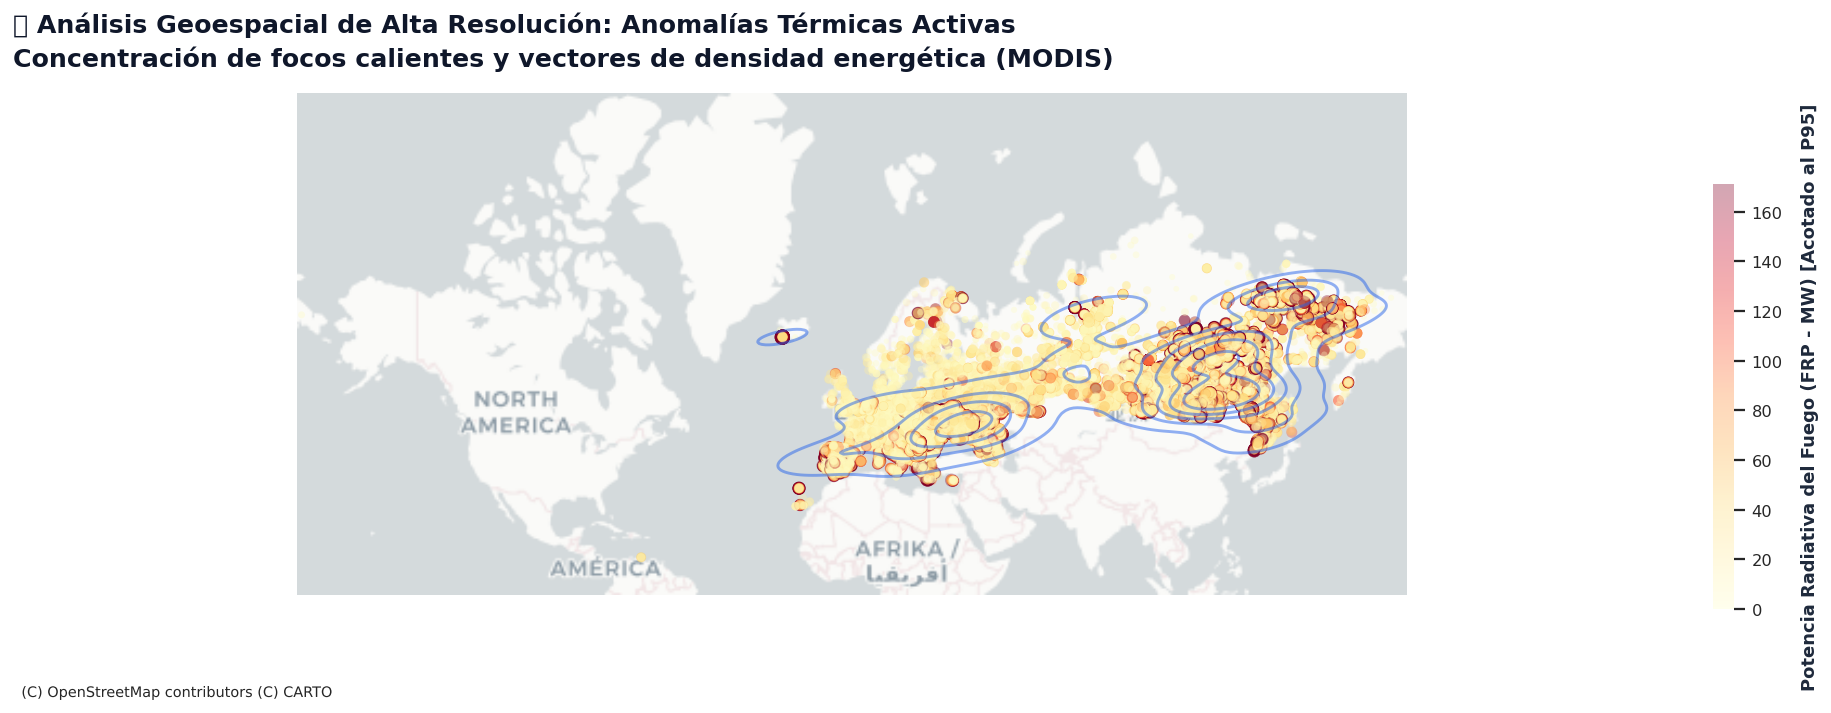

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx

# Configurar entorno estético
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 130

def render_mapa_perfecto(dataframe):
    # 1. Convertir el DataFrame a un GeoDataFrame (fijando WGS84 - EPSG:4326)
    gdf = gpd.GeoDataFrame(
        dataframe,
        geometry=gpd.points_from_xy(dataframe['longitude'], dataframe['latitude']),
        crs="EPSG:4326"
    )

    # 2. Transformar automáticamente a Web Mercator (EPSG:3857), que es el que usa CartoDB
    gdf = gdf.to_crs(epsg=3857)

    # Extraer las coordenadas ya proyectadas de forma segura
    x = gdf.geometry.x
    y = gdf.geometry.y

    # Calcular dimensiones para el aspecto automático
    ancho_datos = x.max() - x.min() if len(x) > 1 else 150000
    alto_datos = y.max() - y.min() if len(y) > 1 else 150000
    aspect_ratio_datos = alto_datos / ancho_datos

    ancho_fig = 14
    alto_fig = max(6, min(ancho_fig * aspect_ratio_datos, 11))

    fig, ax = plt.subplots(figsize=(ancho_fig, alto_fig), layout="constrained")
    ax.set_aspect('equal', adjustable='datalim')

    v_max = gdf['frp'].quantile(0.95)

    # 3. Graficar focos de calor
    scatter = ax.scatter(
        x=x, y=y,
        c=gdf['frp'], cmap='YlOrRd',
        s=np.log1p(gdf['frp']) * 8,
        alpha=0.35,
        edgecolors='none',
        norm=plt.Normalize(vmin=0, vmax=v_max),
        zorder=2
    )

    # 4. Curvas KDE con muestreo dinámico
    if len(gdf) > 5000:
        gdf_kde = gdf.sample(5000, random_state=42)
    else:
        gdf_kde = gdf

    sns.kdeplot(
        x=gdf_kde.geometry.x, y=gdf_kde.geometry.y, ax=ax,
        levels=6, color='#2563eb', linewidths=1.6, alpha=0.5,
        zorder=3
    )

    # 5. Mapa base elegante (Ahora sí encajará al 100%)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zorder=1)

    # 6. Padding adaptativo
    pad_x = ancho_datos * 0.08
    pad_y = alto_datos * 0.08
    ax.set_xlim(x.min() - pad_x, x.max() + pad_x)
    ax.set_ylim(y.min() - pad_y, y.max() + pad_y)

    # 7. Limpieza y Barra de color
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.7)
    cbar.set_label('Potencia Radiativa del Fuego (FRP - MW) [Acotado al P95]',
                   fontsize=10, fontweight='semibold', labelpad=10, color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False)

    plt.title('🗺️ Análisis Geoespacial de Alta Resolución: Anomalías Térmicas Activas\n'
              'Concentración de focos calientes y vectores de densidad energética (MODIS)',
              fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.4)

    sns.despine(left=True, bottom=True)
    return fig

# Ejecutar
fig_mapa_premium = render_mapa_perfecto(df_clean)
plt.show()



###Predicción de Severidad del Incendio (Regresión)

In [19]:
import pandas as pd
import numpy as np
import joblib  # Para guardar el modelo entrenado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"Dataset cargado con {len(df):,} filas.")

# 2. Selección de variables
# Usamos las coordenadas, temperaturas de brillo, geometrías del satélite y si es Día/Noche
features = ['latitude', 'longitude', 'brightness', 'bright_t31', 'scan', 'track', 'confidence', 'daynight']
target = 'frp'

# Limpieza rápida por seguridad (eliminar nulos en estas columnas)
df_ml = df[features + [target]].dropna()

# 3. Codificación de variables cualitativas
# Convertimos 'daynight' ('D' / 'N') a formato numérico (1 / 0)
le_daynight = LabelEncoder()
df_ml['daynight'] = le_daynight.fit_transform(df_ml['daynight'])

X = df_ml[features]
y = df_ml[target]

# 4. División en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {X_train.shape[0]:,} muestras.")
print(f"Tamaño de evaluación: {X_test.shape[0]:,} muestras.")

# 5. Configuración y Entrenamiento del Modelo
print("\nEntrenando el Regresor (Random Forest)... Esto puede tomar un momento...")
# Usamos n_jobs=-1 para aprovechar todos los núcleos de tu procesador
modelo_severidad = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
modelo_severidad.fit(X_train, y_train)

# 6. Evaluación del rendimiento
y_pred = modelo_severidad.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n================ METRICAS DE EVALUACIÓN ================")
print(f"📊 Coeficiente de Determinación (R²): {r2:.4f} (Explica el {r2*100:.1f}% de la varianza)")
print(f"🎯 Error Absoluto Medio (MAE): {mae:.2f} MW")
print(f"📉 Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} MW")
print("========================================================")

# 7. Importancia de las variables (¿Qué influye más en la severidad?)
importancias = pd.Series(modelo_severidad.feature_importances_, index=features).sort_values(ascending=False)
print("\n🔥 Importancia de las variables en la severidad:")
for var, imp in importancias.items():
    print(f"   • {var}: {imp*100:.2f}%")

# 8. GUARDAR EL MODELO Y EL ENCODER
# Esto te permitirá cargarlos en tu aplicación de Streamlit sin volver a entrenar
joblib.dump(modelo_severidad, "modelo_severidad_frp.pkl")
joblib.dump(le_daynight, "encoder_daynight.pkl")
print("\n¡Modelo y transformadores guardados exitosamente!")

Dataset cargado con 308,402 filas.
Tamaño de entrenamiento: 246,721 muestras.
Tamaño de evaluación: 61,681 muestras.

Entrenando el Regresor (Random Forest)... Esto puede tomar un momento...

================ METRICAS DE EVALUACIÓN ================
📊 Coeficiente de Determinación (R²): 0.9491 (Explica el 94.9% de la varianza)
🎯 Error Absoluto Medio (MAE): 3.86 MW
📉 Raíz del Error Cuadrático Medio (RMSE): 29.72 MW

🔥 Importancia de las variables en la severidad:
   • brightness: 65.89%
   • scan: 23.84%
   • longitude: 4.22%
   • track: 2.59%
   • bright_t31: 1.68%
   • latitude: 0.77%
   • confidence: 0.55%
   • daynight: 0.47%

¡Modelo y transformadores guardados exitosamente!


###Detección de Anomalías Térmicas Extremas mediante Isolation Forest

In [20]:
import pandas as pd
import numpy as np
import joblib  # Para guardar el modelo
from sklearn.ensemble import IsolationForest

print(f"Dataset cargado con {len(df):,} focos térmicos.")

# 2. Selección de Variables Críticas para el Modelo
# Nos basamos en las características puramente térmicas que definen la magnitud del evento
features_anomaly = ['brightness', 'bright_t31', 'frp']

# Eliminamos valores nulos en estas columnas por seguridad
df_ml = df.dropna(subset=features_anomaly).copy()

X = df_ml[features_anomaly]

# 3. Configuración y Entrenamiento de Isolation Forest
print("\nEntrenando el detector de anomalías (Isolation Forest)...")

# 'contamination=0.02' define que esperamos que aproximadamente el 2% de los datos sean anomalías extremas.
# Puedes ajustar este parámetro (ej: 0.01 para el 1% o 0.05 para el 5%) según tus necesidades.
modelo_anomalias = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)

# Al ser aprendizaje no supervisado, se entrena directamente con todo el bloque de características
modelo_anomalias.fit(X)

# 4. Predicción de Anomalías
# El modelo devuelve: 1 para registros normales, -1 para anomalías
df_ml['anomaly_label'] = modelo_anomalias.predict(X)

# Convertimos a etiquetas legibles para el análisis
df_ml['tipo_alerta'] = df_ml['anomaly_label'].map({1: 'Normal', -1: 'Anomalía Extrema'})

# 5. Resumen del Análisis
total_anomalias = (df_ml['anomaly_label'] == -1).sum()
total_normales = (df_ml['anomaly_label'] == 1).sum()

print("\n================ RESUMEN DE DETECCIONES ================")
print(f"⚪ Focos dentro del comportamiento normal: {total_normales:,}")
print(f"🚨 Focos clasificados como Anomalías Extremas: {total_anomalias:,}")
print("========================================================")

# 6. Estadísticas comparativas para justificar el modelo
print("\n🔥 Comportamiento térmico promedio por categoría:")
resumen_stats = df_ml.groupby('tipo_alerta')[features_anomaly].mean()
print(resumen_stats)

# 7. Guardar el modelo entrenado y el dataset etiquetado
# Guardamos el modelo en formato .pkl para usarlo en la app web
joblib.dump(modelo_anomalias, "detector_anomalias_isoforest.pkl")

# Exportamos el nuevo dataset con las alertas integradas
df_ml.to_csv("modis_2024_con_anomalias.csv", index=False)
print("\n✅ ¡Modelo guardado como 'detector_anomalias_isoforest.pkl' y dataset exportado con éxito!")

Dataset cargado con 308,402 focos térmicos.

Entrenando el detector de anomalías (Isolation Forest)...

================ RESUMEN DE DETECCIONES ================
⚪ Focos dentro del comportamiento normal: 302,233
🚨 Focos clasificados como Anomalías Extremas: 6,169

🔥 Comportamiento térmico promedio por categoría:
                  brightness  bright_t31         frp
tipo_alerta                                         
Anomalía Extrema  405.234187  308.180840  637.144853
Normal            322.441124  293.277073   39.589633

✅ ¡Modelo guardado como 'detector_anomalias_isoforest.pkl' y dataset exportado con éxito!


###Predicción de Propagación del Fuego mediante Clasificación por Ventanas Temporales

In [21]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Convertir la columna de tiempo a datetime y extraer solo la fecha
df['acq_datetime'] = pd.to_datetime(df['acq_datetime'])
df['fecha'] = df['acq_datetime'].dt.date

print(f"Dataset cargado con {len(df):,} registros.")

# 2. INGENIERÍA DE CARACTERÍSTICAS (Construcción del Target: Propagación)
print("Calculando ventanas de propagación temporal (próximas 24h)...")

# Para optimizar el cálculo con 300k filas, agrupamos por fecha
fechas_unicas = sorted(df['fecha'].unique())
df['se_propaga'] = 0  # Inicializar variable objetivo en 0 (falso)

# Factor de conversión aproximado: 1 grado de latitud/longitud equivale a ~111 km
# Un radio de 10 km equivale aproximadamente a 0.09 grados de margen
RADIO_GRADOS = 0.09

# Iteramos día a día comparando el día actual con el día siguiente
for i in range(len(fechas_unicas) - 1):
    dia_actual = fechas_unicas[i]
    dia_siguiente = fechas_unicas[i+1]

    # Extraer focos de ambos días contiguos
    focos_hoy = df[df['fecha'] == dia_actual]
    focos_manana = df[df['fecha'] == dia_siguiente]

    if focos_manana.empty:
        continue

    # Extraer coordenadas de mañana para vectorizar la búsqueda
    lat_manana = focos_manana['latitude'].values
    lon_manana = focos_manana['longitude'].values

    # Para cada foco de hoy, verificar si hay vecinos mañana a menos de 10km
    indices_propagados = []
    for idx, row in focos_hoy.iterrows():
        # Distancia absoluta rápida en grados (Caja delimitadora)
        cercanos = (np.abs(lat_manana - row['latitude']) < RADIO_GRADOS) & \
                   (np.abs(lon_manana - row['longitude']) < RADIO_GRADOS)

        if np.any(cercanos):
            indices_propagados.append(idx)

    # Marcar los focos del día actual que sí se propagaron mañana
    df.loc[indices_propagados, 'se_propaga'] = 1

# 3. SELECCIÓN DE CARACTERÍSTICAS PARA EL MODELO PREDICTIVO
features = ['latitude', 'longitude', 'brightness', 'bright_t31', 'frp', 'confidence', 'scan', 'track', 'daynight']
target = 'se_propaga'

df_ml = df[features + [target]].dropna().copy()

# Codificar variable categórica daynight
le_dn = LabelEncoder()
df_ml['daynight'] = le_dn.fit_transform(df_ml['daynight'])

X = df_ml[features]
y = df_ml[target]

# 4. DIVISIÓN DEL DATASET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDistribución del Target (Se Propaga):")
print(y.value_counts(normalize=True))

# 5. ENTRENAMIENTO DEL MODELO DE GRADIENT BOOSTING
print("\nEntrenando clasificador de propagación temporal...")
# Usamos HistGradientBoostingClassifier porque maneja millones de filas de forma nativa e hiperveloz
modelo_propagacion = HistGradientBoostingClassifier(random_state=42, max_iter=150, learning_rate=0.1)
modelo_propagacion.fit(X_train, y_train)

# 6. EVALUACIÓN DEL RENDIMIENTO
y_pred = modelo_propagacion.predict(X_test)

print("\n================ EVALUACIÓN DEL MODELO ================")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["Contenido / Apagado", "Se Propaga (Riesgo Activo)"]))
print("========================================================")

# 7. GUARDAR EL PRODUCTO ENTRENADO
joblib.dump(modelo_propagacion, "modelo_propagacion_fuego.pkl")
joblib.dump(le_dn, "encoder_daynight_prop.pkl")
print("\n✅ ¡Modelo guardado con éxito como 'modelo_propagacion_fuego.pkl'!")

Dataset cargado con 308,402 registros.
Calculando ventanas de propagación temporal (próximas 24h)...

Distribución del Target (Se Propaga):
se_propaga
1    0.630849
0    0.369151
Name: proportion, dtype: float64

Entrenando clasificador de propagación temporal...

================ EVALUACIÓN DEL MODELO ================
Exactitud Global (Accuracy): 0.7823

Reporte de Clasificación:
                            precision    recall  f1-score   support

       Contenido / Apagado       0.77      0.59      0.67     22770
Se Propaga (Riesgo Activo)       0.79      0.89      0.84     38911

                  accuracy                           0.78     61681
                 macro avg       0.78      0.74      0.75     61681
              weighted avg       0.78      0.78      0.78     61681


✅ ¡Modelo guardado con éxito como 'modelo_propagacion_fuego.pkl'!


###Clasificación del Tipo de Foco con Balanceo de Clases (SMOTE)

In [22]:
import pandas as pd
import numpy as np
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

def entrenamiento_seguro_sin_smote():
    t_inicio = time.time()

    # 1. Leer el archivo físico
    print("🚀 [PASO 1] Leyendo archivo de datos...")
    ruta_csv = "data/modis_2024_unificado_limpio.csv"
    df_fresco = pd.read_csv(ruta_csv)
    print(f"-> Total de filas cargadas: {len(df_fresco):,}")

    # 2. Mapeo explícito de categorías
    dicc_categorias = {
        'Incendio forestal/vegetación': 0,
        'Industria/Foco estático': 1,
        'Otros/Fuera de rango': 2,
        'Volcán': 3
    }

    # Convertimos a números controlando nulos
    y_fresca = df_fresco['type'].map(dicc_categorias).fillna(0).astype(int)
    dn_fresco = np.where(df_fresco['daynight'].astype(str).str.strip().str.upper() == 'N', 1, 0)

    # Construcción de la matriz de entrada
    X_fresco = pd.DataFrame({
        'latitude': df_fresco['latitude'].astype(float),
        'longitude': df_fresco['longitude'].astype(float),
        'brightness': df_fresco['brightness'].astype(float),
        'bright_t31': df_fresco['bright_t31'].astype(float),
        'frp': df_fresco['frp'].astype(float),
        'confidence': df_fresco['confidence'].astype(float),
        'daynight_num': dn_fresco
    }).fillna(0.0)

    print("\n🚀 [PASO 2] Distribución real de las clases detectadas en el archivo:")
    print(y_fresca.value_counts())

    # 3. División del dataset SIMPLE (Sin stratify para evitar bloqueos si hay corrupción de etiquetas)
    print("\n🚀 [PASO 3] Dividiendo datos en entrenamiento y prueba...")
    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        X_fresco, y_fresca, test_size=0.2, random_state=42
    )

    # 4. Escalado de variables
    print("🚀 [PASO 4] Escalando características numéricas...")
    escalador_f = StandardScaler()
    X_train_scaled_f = escalador_f.fit_transform(X_train_f)
    X_test_scaled_f = escalador_f.transform(X_test_f)

    # 5. Entrenamiento con Pesos Balanceados (Reemplazo nativo y seguro de SMOTE)
    print("\n🚀 [PASO 5] Entrenando Random Forest con penalización de pesos balanceados...")
    # Usamos class_weight='balanced' para obligar al modelo a aprender de las clases con pocas muestras
    bosque_modelo = RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        max_depth=15,
        class_weight='balanced'
    )
    bosque_modelo.fit(X_train_scaled_f, y_train_f)
    print("✅ ¡Modelo entrenado!")

    # 6. Evaluación de resultados
    print("\n🚀 [PASO 6] Evaluando el rendimiento del clasificador...")
    y_predicciones = bosque_modelo.predict(X_test_scaled_f)

    # Identificar qué clases se mantuvieron vivas en el set de prueba
    clases_presentes = np.unique(y_test_f)
    nombres_base = {0: 'Incendio', 1: 'Industria', 2: 'Otros', 3: 'Volcán'}
    nombres_reporte = [nombres_base[c] for c in clases_presentes]

    print("\n================ 📊 REPORTE DE CLASIFICACIÓN FINAL ================")
    print(classification_report(y_test_f, y_predicciones, target_names=nombres_reporte))
    print("==================================================================")

    # 7. Exportación de archivos binarios para tu aplicación de Streamlit
    print("\n🚀 [PASO 7] Guardando archivos de producción...")
    joblib.dump(bosque_modelo, "clasificador_tipos_smote.pkl") # Mantenemos el nombre para no romper tu Streamlit
    joblib.dump(escalador_f, "escalador_features.pkl")
    joblib.dump(dicc_categorias, "mapeo_textos_a_numeros.pkl")
    print(f"✅ ¡Todo el proceso completado con éxito en {time.time() - t_inicio:.1f} segundos!")

# Ejecutar el pipeline seguro
entrenamiento_seguro_sin_smote()

🚀 [PASO 1] Leyendo archivo de datos...
-> Total de filas cargadas: 308,402

🚀 [PASO 2] Distribución real de las clases detectadas en el archivo:
type
0    308402
Name: count, dtype: int64

🚀 [PASO 3] Dividiendo datos en entrenamiento y prueba...
🚀 [PASO 4] Escalando características numéricas...

🚀 [PASO 5] Entrenando Random Forest con penalización de pesos balanceados...
✅ ¡Modelo entrenado!

🚀 [PASO 6] Evaluando el rendimiento del clasificador...

================ 📊 REPORTE DE CLASIFICACIÓN FINAL ================
              precision    recall  f1-score   support

    Incendio       1.00      1.00      1.00     61681

    accuracy                           1.00     61681
   macro avg       1.00      1.00      1.00     61681
weighted avg       1.00      1.00      1.00     61681


🚀 [PASO 7] Guardando archivos de producción...
✅ ¡Todo el proceso completado con éxito en 3.7 segundos!
